# 신용카드 사용자 연체 예측 AI 경진대회
이 노트북은 Dacon 신용카드 사용자 연체 예측 AI 경진대회의 베이스라인 코드입니다.

## 분석 순서
1. 데이터 로드 및 확인
2. 데이터 전처리 (결측치, 인코딩, 파생변수)
3. 데이터 탐색 (EDA)
4. 모델링 (RandomForest Baseline)
5. 제출 파일 생성

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 한글 폰트 설정 (Windows: Malgun Gothic)
plt.rc('font', family='Malgun Gothic')
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

## 1. 데이터 로드

In [2]:
try:
    train = pd.read_csv('../data/train.csv')
    test = pd.read_csv('../data/test.csv')
    submission = pd.read_csv('../data/sample_submission.csv')
    print("데이터 로드 완료")
    print(f"원본 Train 컬럼 수: {len(train.columns)}")
    print(f"원본 Test 컬럼 수: {len(test.columns)}")
except FileNotFoundError:
    print("데이터 파일이 ../data/ 폴더에 있는지 확인해주세요.")

데이터 로드 완료
원본 Train 컬럼 수: 20
원본 Test 컬럼 수: 19


## 2. 데이터 전처리 및 인코딩
- 결측치 처리 (occyp_type)
- 파생변수 생성 (age, worked_years)
- 범주형 변수 인코딩 (Label Encoding)
- 불필요한 컬럼 삭제

In [3]:
def preprocess_data(df):
    # 결측치 처리: occyp_type (직업 유형)의 결측치를 'None'으로 대체
    df['occyp_type'] = df['occyp_type'].fillna('None')
    
    # DAYS_BIRTH -> age (나이)
    df['age'] = abs(df['DAYS_BIRTH']) // 365
    
    # DAYS_EMPLOYED -> worked_years (근무 연수)
    # 양수(365243)는 무직을 의미하므로 0으로 처리
    df['worked_years'] = df['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else abs(x) // 365)
    
    # begin_month -> 발행된지 몇 달 되었는지 (발행 개월)
    df['begin_month'] = abs(df['begin_month'])
    
    # 불필요한 컬럼 삭제
    df = df.drop(['index', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL'], axis=1, errors='ignore')
    
    return df

In [4]:
if 'train' in locals():
    train_df = preprocess_data(train.copy())
    test_df = preprocess_data(test.copy())
    
    # 인코딩 전 컬럼 수 확인
    print(f"전처리 후 (인코딩 전) Train 컬럼 수: {train_df.shape[1]}")
    
    # Label Encoding
    from sklearn.preprocessing import LabelEncoder
    
    # 범주형 컬럼 리스트 추출
    cat_cols = train_df.select_dtypes(include='object').columns
    print(f"인코딩 대상 범주형 컬럼: {list(cat_cols)}")
    
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([train_df[col], test_df[col]], axis=0)
        le.fit(combined)
        train_df[col] = le.transform(train_df[col])
        test_df[col] = le.transform(test_df[col])
    
    print("\n--- 인코딩 완료 ---")
    print(f"최종 Train 데이터 셋 Shape: {train_df.shape}")
    print(f"최종 Test 데이터 셋 Shape: {test_df.shape}")
    print(f"학습에 사용될 최종 컬럼 수: {train_df.shape[1] - 1} (target 제외)")
    print(f"최종 컬럼 목록: {list(train_df.columns)}")

전처리 후 (인코딩 전) Train 컬럼 수: 18
인코딩 대상 범주형 컬럼: ['gender', 'car', 'reality', 'income_type', 'edu_type', 'family_type', 'house_type', 'occyp_type']

--- 인코딩 완료 ---
최종 Train 데이터 셋 Shape: (26457, 18)
최종 Test 데이터 셋 Shape: (10000, 17)
학습에 사용될 최종 컬럼 수: 17 (target 제외)
최종 컬럼 목록: ['gender', 'car', 'reality', 'child_num', 'income_total', 'income_type', 'edu_type', 'family_type', 'house_type', 'work_phone', 'phone', 'email', 'occyp_type', 'family_size', 'begin_month', 'credit', 'age', 'worked_years']


## 3. 데이터 탐색 (EDA)
직업 유형(occyp_type)의 분포를 막대그래프로 확인합니다.

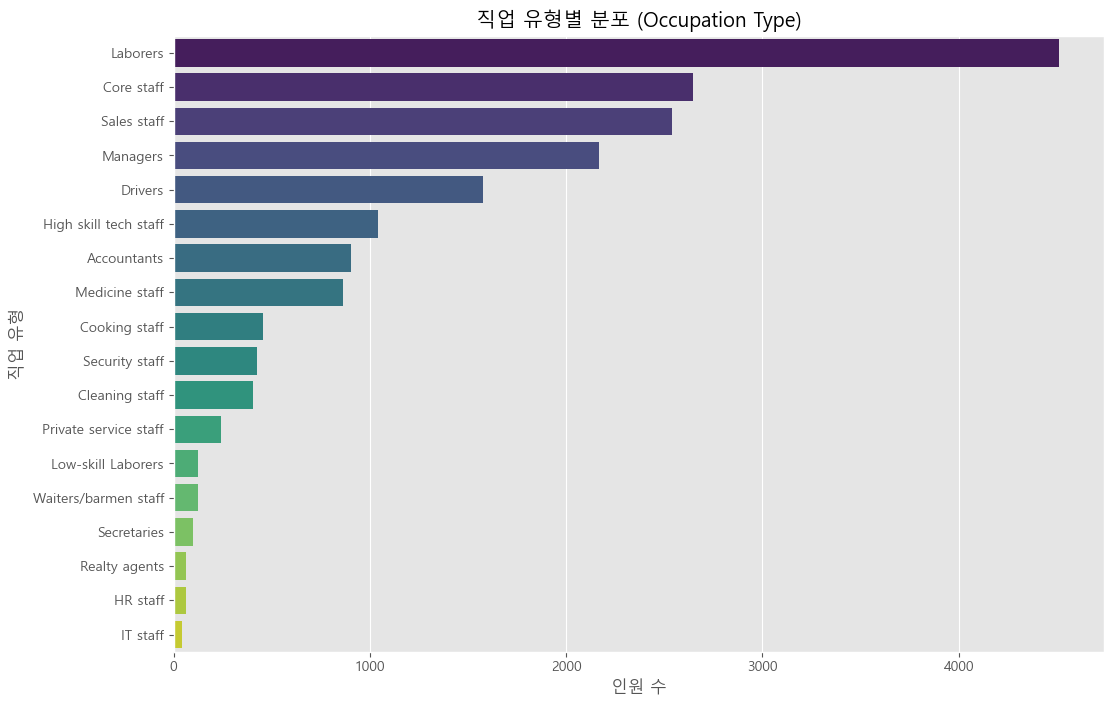

In [5]:
if 'train' in locals():
    plt.figure(figsize=(12, 8))
    sns.countplot(data=train, y='occyp_type', palette='viridis', 
                  order=train['occyp_type'].value_counts().index)
    plt.title('직업 유형별 분포 (Occupation Type)')
    plt.xlabel('인원 수')
    plt.ylabel('직업 유형')
    plt.show()

## 4. 모델링 (RandomForest Baseline)
중복 데이터를 방지하기 위해 Stratified K-Fold를 사용합니다.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

if 'train_df' in locals():
    X = train_df.drop('credit', axis=1)
    y = train_df['credit']
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    rf_models = []
    log_losses = []
    
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"--- Fold {i+1} --- ")
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        y_pred_proba = model.predict_proba(X_val)
        loss = log_loss(y_val, y_pred_proba)
        
        rf_models.append(model)
        log_losses.append(loss)
        print(f"Log Loss: {loss:.4f}")
        
    print(f"평균 Log Loss: {np.mean(log_losses):.4f}")

--- Fold 1 --- 
Log Loss: 0.9199
--- Fold 2 --- 
Log Loss: 0.9375
--- Fold 3 --- 
Log Loss: 0.9450
--- Fold 4 --- 
Log Loss: 0.9082
--- Fold 5 --- 
Log Loss: 0.9776
평균 Log Loss: 0.9376


### 4.1 결측치 확인
데이터셋에 존재하는 결측치를 확인합니다.

In [7]:
if 'train' in locals():
    print("--- Train Data Missing Values ---")
    print(train.isnull().sum())
    print("\n--- Test Data Missing Values ---")
    print(test.isnull().sum())

--- Train Data Missing Values ---
index               0
gender              0
car                 0
reality             0
child_num           0
income_total        0
income_type         0
edu_type            0
family_type         0
house_type          0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
FLAG_MOBIL          0
work_phone          0
phone               0
email               0
occyp_type       8171
family_size         0
begin_month         0
credit              0
dtype: int64

--- Test Data Missing Values ---
index               0
gender              0
car                 0
reality             0
child_num           0
income_total        0
income_type         0
edu_type            0
family_type         0
house_type          0
DAYS_BIRTH          0
DAYS_EMPLOYED       0
FLAG_MOBIL          0
work_phone          0
phone               0
email               0
occyp_type       3152
family_size         0
begin_month         0
dtype: int64


## 5. 최종 예측 및 제출 파일 생성

In [8]:
if 'rf_models' in locals() and rf_models:
    final_preds = np.zeros((test_df.shape[0], 3))
    
    for model in rf_models:
        final_preds += model.predict_proba(test_df) / len(rf_models)
    
    submission.iloc[:, 1:] = final_preds
    import os
    if not os.path.exists('output'):
        os.makedirs('output')
    submission.to_csv('output/baseline_submission.csv', index=False)
    print("제출 파일 저장 완료: output/baseline_submission.csv")

제출 파일 저장 완료: output/baseline_submission.csv
